# Modeling with K-Nearest Neighbors for Red Wine Quality Prediction.
###  Binary Classification

In [247]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### importing the data

In [248]:
redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
113,8.3,0.715,0.15,1.8,0.089,10.0,52.0,0.99680,3.23,0.77,9.5,5
474,11.9,0.380,0.49,2.7,0.098,12.0,42.0,1.00040,3.16,0.61,10.3,5
1361,6.6,0.895,0.04,2.3,0.068,7.0,13.0,0.99582,3.53,0.58,10.8,6
562,8.7,0.540,0.26,2.5,0.097,7.0,31.0,0.99760,3.27,0.60,9.3,6
706,7.4,0.370,0.43,2.6,0.082,18.0,82.0,0.99708,3.33,0.68,9.7,6


### inspecting the dataset , datatypes and names of the columns

In [249]:
redwine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 136.8 KB


### Simple Descriptive Analysis

In [250]:
redwine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,8.312209,0.524155,0.265281,2.388717,0.081580,15.089849,43.662209,0.996718,3.316276,0.642414,10.416975,5.646776
std,1.647586,0.169595,0.191271,0.865307,0.021298,9.317669,29.414125,0.001718,0.141196,0.129753,1.020614,0.801119
min,5.000000,0.120000,0.000000,1.200000,0.038000,1.000000,6.000000,0.991500,2.880000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995600,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,36.000000,0.996700,3.315000,0.620000,10.200000,6.000000
75%,9.200000,0.635000,0.420000,2.600000,0.089000,21.000000,58.000000,0.997800,3.400000,0.720000,11.100000,6.000000
max,13.500000,1.040000,0.790000,6.700000,0.226000,47.000000,145.000000,1.002200,3.750000,1.160000,13.600000,8.000000


### the scater plot describes the relationship between the density and alcohol content of the red wine.
##### the data shows that the density of the red wine is inversely proportional to the alcohol content. The higher the alcohol content, the lower the density of the red wine.

<Axes: xlabel='density', ylabel='alcohol'>

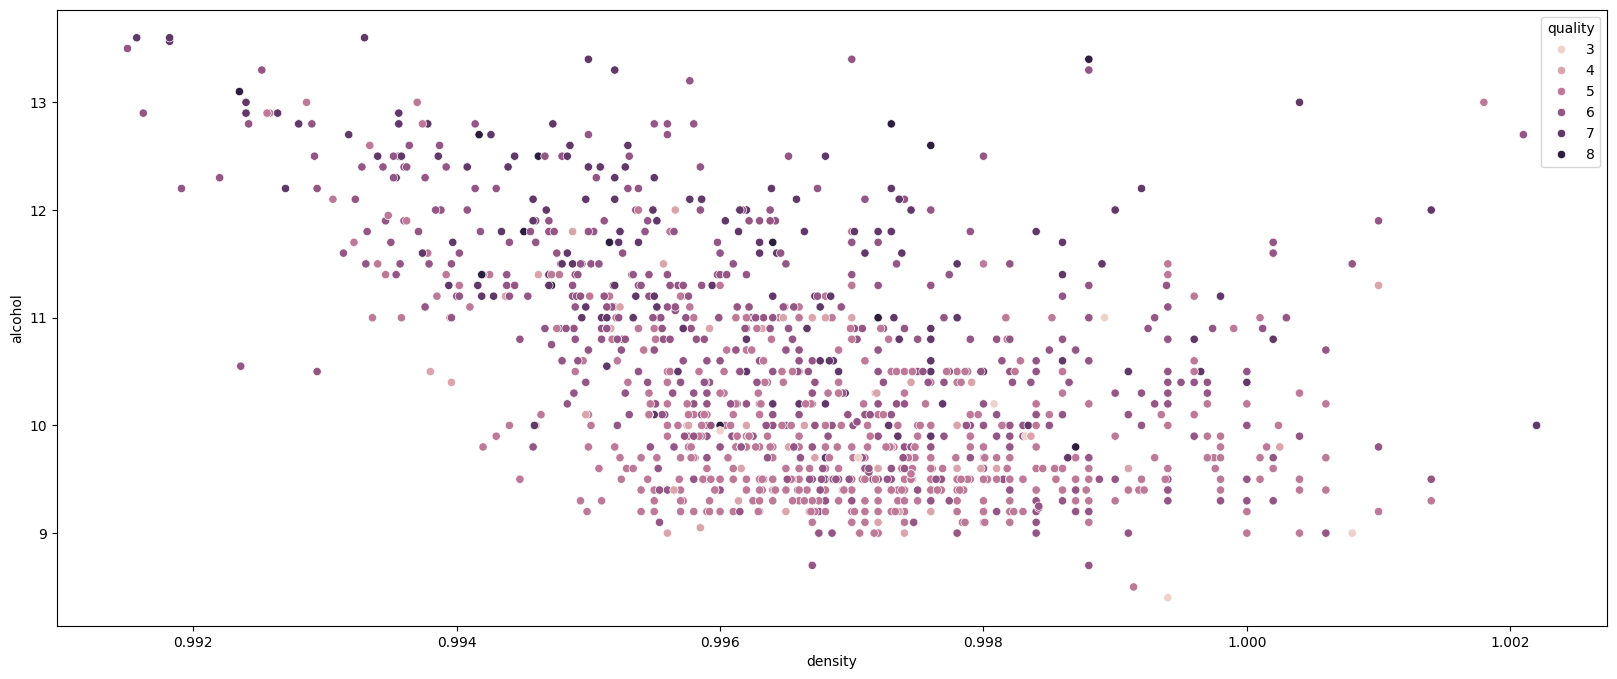

In [251]:
plt.figure(figsize=(20, 8))
sns.scatterplot(x='density', y='alcohol', data= redwine_df, hue='quality')

# Interesting Correlations:

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically.

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.

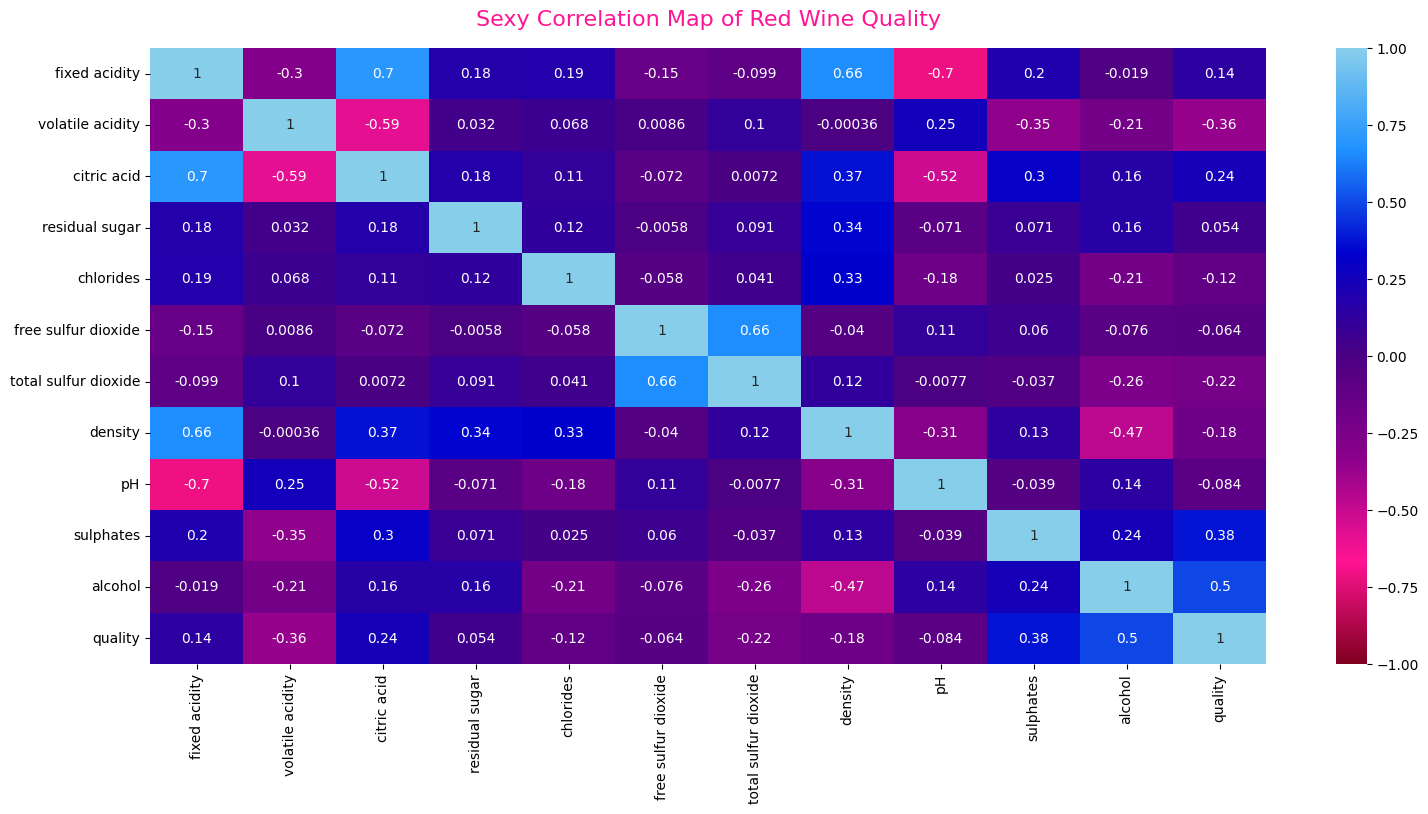

In [252]:
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.pyplot as plt

sexy_palette = mcolors.LinearSegmentedColormap.from_list(
    "sexy", ["#800020", "#FF1493", "#8B008B", "#4B0082", "#0000CD", "#1E90FF", "#87CEEB"])

plt.figure(figsize=(18, 8))

sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap=sexy_palette)

plt.title('Sexy Correlation Map of Red Wine Quality', fontdict={'fontsize':16, 'color': '#FF1493'}, pad=16)

plt.show()


# PreProcessing

In [253]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

- *If the **quality value >= 6**, it means the quality is **good** and I define it as **1**.*
- *If the **quality value < 6,** it means the quality is **bad** and I define it as **0**.*

In [254]:
redwine_df['quality_binary'] = redwine_df['quality'].apply(lambda x: 0 if x in [3, 4, 5] else 1)
quality_counts = redwine_df['quality_binary'].value_counts()

print(quality_counts)

quality_binary
1    787
0    671
Name: count, dtype: int64


In [255]:
# Drop the original 'quality' column (if it's still in the DataFrame)
redwine_df = redwine_df.drop(columns=['quality'], errors='ignore')
# rename the new quality column
redwine_df = redwine_df.rename(columns={'quality_binary': 'quality'})
# Display a sample of 10 rows
redwine_df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,36.5,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,1
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,0


## Find Best K-Score

#### steps
#### 1- splitting the data to train and test
#### 2- finding the best K value. (K value is a value that represents the number of neighbours that the algorithm can take in to account in order to classify )


In [256]:
X = redwine_df.drop(['quality'], axis = 1)
y = redwine_df['quality']

# Understanding the Effect of K in K-Nearest Neighbors (KNN)

In **K-Nearest Neighbors (KNN)**, the choice of **K** (the number of nearest neighbors considered) significantly affects the model’s behavior and performance. Here's how the value of **K** influences the model:

## 1. Low K Value (Small K, e.g., K=1 or 3):
- **High variance**: A low **K** means the model only considers a small number of neighbors (even just one in the case of **K=1**). This can lead to a model that is very sensitive to noise and variations in the training data.
- **Overfitting risk**: The model is more likely to overfit, as it may "memorize" the training data and make decisions based on very specific local patterns, even if those patterns are not representative of the overall data.
- **More complex decision boundaries**: With a low **K**, the decision boundaries between different classes will be more jagged and sensitive to individual data points.

### Example Behavior for Low K:
- **K=1**: The model will classify a new point based solely on the closest single data point. If that point is a noisy or outlier point, the classification could be wrong.
- **K=3**: The model will consider the 3 nearest neighbors and classify the new point based on the majority class among those three. This smooths the classification slightly but can still be prone to noise and overfitting.

**Visual impact**: A small **K** results in more complex and jagged decision boundaries that closely follow individual data points.

---

## 2. High K Value (Large K, e.g., K=10 or 15):
- **Low variance, high bias**: As **K** increases, the model considers more neighbors when making a prediction, which leads to smoother decision boundaries. However, if **K** is too high, the model may oversimplify the classification.
- **Underfitting risk**: A very high **K** could cause underfitting, where the model loses the ability to capture local patterns or important details in the data. It becomes too general, as it averages too many neighbors' decisions, potentially blending different class boundaries.
- **Smoother decision boundaries**: With a higher **K**, the decision boundaries become smoother, and the model is less sensitive to noise in the data. It generalizes better but may miss important local patterns.

### Example Behavior for High K:
- **K=15**: The model will classify a new point based on the majority class among the 15 nearest neighbors. This means the decision is made by considering a larger context around the point, leading to smoother boundaries.
- **K=50**: If **K** is very large relative to the size of the dataset, the model might start considering points that are far away and irrelevant, which can cause it to misclassify points near decision boundaries.

**Visual impact**: A large **K** results in smoother decision boundaries, as the model takes into account many neighbors' labels, leading to more general classifications.

---

## Trade-Offs Between High and Low K:
- **Low K (small K)**:
  - **Pros**: Captures local patterns, can model more complex relationships in the data.
  - **Cons**: Prone to overfitting, sensitive to noise, and high variance.

- **High K (large K)**:
  - **Pros**: Smoother, more general decision boundaries; less sensitive to noise and outliers.
  - **Cons**: Prone to underfitting, might miss important local patterns.


## Conclusion:
- A **low K** captures **local** patterns but risks overfitting and reacting to noise in the data.
- A **high K** smooths out the predictions, reducing the chance of overfitting, but might lead to **underfitting** by oversimplifying the decision boundaries.

The **optimal K** depends on the data, and typically, **cross-validation** is used to find the best value for **K** that balances variance and bias.


# Find best K
#### this method is going to identify which K score is the best score for my dataset based on train test splitting of the data.

In [257]:
from sklearn.model_selection import train_test_split, cross_val_score

def find_best_k(X_train, y_train, X_test, y_test, k_range=(1, 50, 1)):
    """
    Finds the best K value for KNeighborsClassifier using cross-validation and records training/testing accuracy.

    Parameters:
    X_train: Features for training the model
    y_train: Labels for training the model
    X_test: Features for testing the model
    y_test: Labels for testing the model
    k_range: A tuple (start, stop, step) representing the range of K values to test

    Returns:
    best_k: The K value that gives the highest cross-validated accuracy score
    best_score: The highest accuracy score
    training_accuracy: List of training accuracy scores for each K value
    testing_accuracy: List of testing accuracy scores for each K value
    """

    # Extract the range of K values to test
    k_values = range(k_range[0], k_range[1], k_range[2])

    # Lists to hold the accuracy scores for each K value
    training_accuracy = []
    testing_accuracy = []
    
    # Loop over the different K values
    for k in k_values:
        # Define the KNN model with current K value
        knn = KNeighborsClassifier(n_neighbors=k)
        # Create a pipeline with MinMaxScaler and KNN
        pipeline = Pipeline([('scaler', MinMaxScaler()), ('knn', knn)])
        
        # Fit the pipeline on the training data
        pipeline.fit(X_train, y_train)
        
        # Predict on the training data
        y_train_pred = pipeline.predict(X_train)
        train_acc = accuracy_score(y_train, y_train_pred)
        training_accuracy.append(train_acc)
        
        # Predict on the testing data
        y_test_pred = pipeline.predict(X_test)
        test_acc = accuracy_score(y_test, y_test_pred)
        testing_accuracy.append(test_acc)
    
    # Get the best K value based on the test accuracy
    best_score = max(testing_accuracy)
    best_k = k_values[testing_accuracy.index(best_score)]

    print(f"Best K: {best_k} with test accuracy: {best_score:.4f}")
    
    return best_k, best_score, training_accuracy, testing_accuracy



## K-Nearest Neighbors (KNN) Training vs Testing Accuracy for Different Values of K

1. **Training Accuracy (Blue Line)**:
    - Initially, the training accuracy is very high for low K values, suggesting potential overfitting.
    - As K increases, the training accuracy decreases, indicating that the model becomes less specific to the training data.
    - The training accuracy stabilizes around K = 9, reaching a plateau.

2. **Testing Accuracy (Orange Line)**:
    - Testing accuracy starts low but increases as K increases.
    - The highest test accuracy is observed around K = 9, indicating that this value of K generalizes best to unseen data.
    - Beyond K = 9, the testing accuracy decreases or remains stable, suggesting that larger K values may underfit the data.

3. **Best K Value**:
    - The best value of K is 9, as indicated at the top of the graph, with a test accuracy of approximately 0.7551.

### Conclusion:
- A K value of 9 seems to provide the optimal balance between high training accuracy and improved generalization to the test set.
- Lower K values lead to overfitting (high training accuracy but low testing accuracy), while higher K values result in underfitting (both accuracies decrease).


Best K: 9 with test accuracy: 0.7551


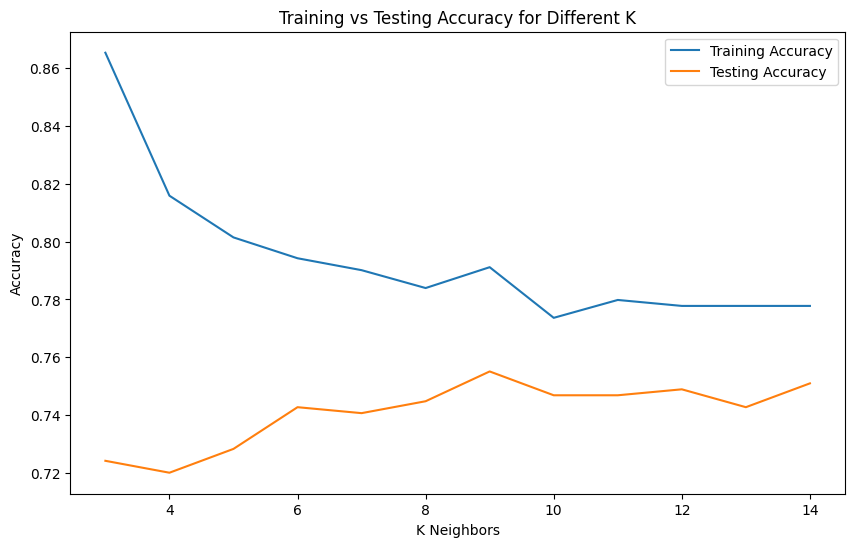

In [258]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.333, random_state=42)

best_k, best_score, training_accuracy, testing_accuracy = find_best_k(X_train, y_train, X_test, y_test, k_range=(3, 15, 1))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(3, 15), y=training_accuracy, label="Training Accuracy")
sns.lineplot(x=range(3, 15), y=testing_accuracy, label="Testing Accuracy")
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy for Different K")
plt.legend()
plt.show()


In [259]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

# Use K=9 and Ball Tree algorithm for KNN
knn = KNeighborsClassifier(n_neighbors=9, weights='distance', algorithm='ball_tree')

# Create a pipeline that scales the data and applies the KNN classifier
pipe_knn = Pipeline([('scale', MinMaxScaler()), ('knn', knn)])

# Fit the model to the training data
pipe_knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipe_knn.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with K=9 and Ball Tree: {accuracy:.4f}")

# Display detailed performance metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy with K=9 and Ball Tree: 0.8107
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.77      0.78       207
           1       0.83      0.84      0.84       279

    accuracy                           0.81       486
   macro avg       0.81      0.81      0.81       486
weighted avg       0.81      0.81      0.81       486



## ROC Curve for KNN Model

### Key Points:
- The curve indicates how well the model distinguishes between the positive and negative classes.
- The **AUC (Area Under the Curve)** value is **0.89**, which suggests that the model has good classification performance. An AUC value closer to 1.0 represents better performance.
  
### Conclusion:
- The KNN model demonstrates strong predictive capability with an AUC of 0.89, meaning it can effectively differentiate between classes.


# HyperParameter Tuning

In [261]:
from pprint import pprint
pprint(pipe_knn.get_params(), indent=4)

{   'knn': KNeighborsClassifier(algorithm='ball_tree', n_neighbors=9, weights='distance'),
    'knn__algorithm': 'ball_tree',
    'knn__leaf_size': 30,
    'knn__metric': 'minkowski',
    'knn__metric_params': None,
    'knn__n_jobs': None,
    'knn__n_neighbors': 9,
    'knn__p': 2,
    'knn__weights': 'distance',
    'memory': None,
    'scale': MinMaxScaler(),
    'scale__clip': False,
    'scale__copy': True,
    'scale__feature_range': (0, 1),
    'steps': [   ('scale', MinMaxScaler()),
                 (   'knn',
                     KNeighborsClassifier(algorithm='ball_tree', n_neighbors=9, weights='distance'))],
    'verbose': False}


Best hyperparameters found:  {'knn__n_neighbors': 13, 'knn__p': 2, 'knn__weights': 'distance'}
Best accuracy score from GridSearchCV: 0.7932
Test Accuracy after Hyperparameter Tuning: 0.8025
Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77       207
           1       0.83      0.83      0.83       279

    accuracy                           0.80       486
   macro avg       0.80      0.80      0.80       486
weighted avg       0.80      0.80      0.80       486



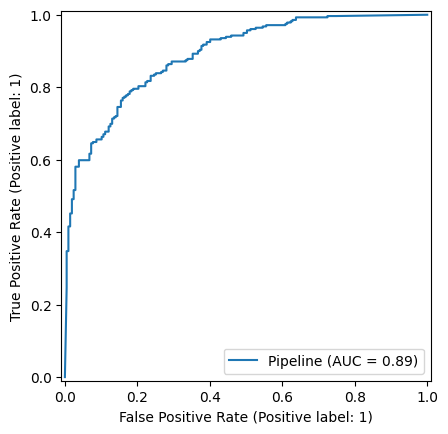

In [262]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13],      # Number of neighbors to consider
    'knn__weights': ['uniform', 'distance'],# How to weight the neighbors
    'knn__p': [1, 2]                       # Power parameter for the Minkowski distance (1: Manhattan, 2: Euclidean)
}

grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best hyperparameters found: ", grid_search.best_params_)

best_score = grid_search.best_score_
print(f"Best accuracy score from GridSearchCV: {best_score:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Test Accuracy after Hyperparameter Tuning: {accuracy_score(y_test, y_pred_best):.4f}")
print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred_best))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()
